### Linear Regression : Multinomial

In [47]:
# import libraries
import pandas as pd
import numpy as np
# import pymysql
from dotenv import load_dotenv
import os
from sqlalchemy import create_engine

import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

# setting to show all columns of data frames
pd.set_option('display.max_columns', None)

In [48]:
# load .env; loads credentials into memeory 
load_dotenv(override=True)

True

In [49]:
host=os.getenv('DB_HOST')
user=os.getenv('DB_USER')
password=os.getenv('DB_PASSWORD')
database=os.getenv('DB_NAME')

In [50]:
# select data from admission_source table
connection_string = f"mysql+pymysql://{user}:{password}@{host}/{database}"
try:
    engine = create_engine(connection_string)

    with engine.connect() as conn:
        admission_source_df = pd.read_sql('''SELECT * FROM admission_source;''', con = conn)

        conn.close()

except (Exception) as error:
        error_log   = 'Error selecting data from admission_source table. Check system file.'                  
        with open('error_log.txt','w') as error:
           error.write(error_log)


admission_source_df.head()

,admission_source_id,admission_source_description
0,1,Physician Referral
1,2,Clinic Referral
2,3,HMO Referral
3,4,Transfer from a hospital
4,5,Transfer from a Skilled Nursing Facility (SNF)


In [51]:
# select data from admission_type table
connection_string = f"mysql+pymysql://{user}:{password}@{host}/{database}"
try:
    engine = create_engine(connection_string)

    with engine.connect() as conn:
        admission_type_df = pd.read_sql('''SELECT * FROM admission_type;''', con = conn)

        conn.close()

except (Exception) as error:
        error_log   = 'Error selecting data from admission_type table. Check system file.'                  
        with open('error_log.txt','w') as error:
           error.write(error_log)


admission_type_df.head()

,admission_type_id,admission_type_description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available


In [52]:
# select data from discharge_disposition table
connection_string = f"mysql+pymysql://{user}:{password}@{host}/{database}"
try:
    engine = create_engine(connection_string)

    with engine.connect() as conn:
        discharge_disposition_df = pd.read_sql('''SELECT * FROM discharge_disposition;''', con = conn)

        conn.close()

except (Exception) as error:
        error_log   = 'Error selecting data from discharge_disposition table. Check system file.'                  
        with open('error_log.txt','w') as error:
           error.write(error_log)


discharge_disposition_df.head()

,discharge_disposition_id,discharge_disposition_description
0,1,Discharged to home
1,2,Discharged/transferred to another short term h...
2,3,Discharged/transferred to SNF
3,4,Discharged/transferred to ICF
4,5,Discharged/transferred to another type of inpa...


In [53]:
# select data from icd9 table
connection_string = f"mysql+pymysql://{user}:{password}@{host}/{database}"
try:
    engine = create_engine(connection_string)

    with engine.connect() as conn:
        icd9_df = pd.read_sql('''SELECT * FROM icd9;''', con = conn)

        conn.close()

except (Exception) as error:
        error_log   = 'Error selecting data from icd9 table. Check system file.'                  
        with open('error_log.txt','w') as error:
           error.write(error_log)


icd9_df.head()

,id,code_start_str,code_end_str,code_start_int,code_end_int,icd9_description
0,1,NaN,NaN,1.0,139.0,INFECTIOUS AND PARASITIC DISEASES (001-139)
1,2,NaN,NaN,140.0,239.0,NEOPLASMS (140-239)
2,3,NaN,NaN,240.0,279.0,"ENDOCRINE, NUTRITIONAL AND METABOLIC DISEASES,..."
3,4,NaN,NaN,280.0,289.0,DISEASES OF THE BLOOD AND BLOOD-FORMING ORGANS...
4,5,NaN,NaN,290.0,319.0,"MENTAL, BEHAVIORAL AND NEURODEVELOPMENTAL DISO..."


In [54]:
# select data from patient table
connection_string = f"mysql+pymysql://{user}:{password}@{host}/{database}"
try:
    engine = create_engine(connection_string)

    with engine.connect() as conn:
        patient = pd.read_sql('''SELECT * FROM patient;''', con = conn)

        conn.close()

except (Exception) as error:
        error_log   = 'Error selecting data from patient table. Check system file.'                  
        with open('error_log.txt','w') as error:
           error.write(error_log)


patient.head()

,patient_nbr,race,gender,age,weight,created_date,last_modified
0,135,Caucasian,Female,50-60,Not Captured,2026-05-04 19:13:04,2026-05-04 19:13:04
1,378,Caucasian,Female,50-60,Not Captured,2026-05-04 19:13:04,2026-05-04 19:13:04
2,729,Caucasian,Female,80-90,Not Captured,2026-05-04 19:13:04,2026-05-04 19:13:04
3,774,Caucasian,Female,80-90,Not Captured,2026-05-04 19:13:04,2026-05-04 19:13:04
4,927,African American,Female,30-40,Not Captured,2026-05-04 19:13:04,2026-05-04 19:13:04


In [55]:
# select records from the patient_encouonter table
connection_string = f"mysql+pymysql://{user}:{password}@{host}/{database}"
try:
    engine = create_engine(connection_string)

    with engine.connect() as conn:
        patient_encounter = pd.read_sql('''SELECT patient_nbr,encounter_id
                                            ,admission_type_id
                                            ,admission_source_id
                                            ,discharge_disposition_id
                                            ,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures
                                            ,num_medications,number_outpatient,number_emergency,number_inpatient
                                            ,pe.diag_1,icd9_1.icd9_description AS diag_1_desc
                                            ,pe.diag_2,icd9_2.icd9_description AS diag_2_desc
                                            ,pe.diag_3,icd9_3.icd9_description AS diag_3_desc
                                            ,number_diagnoses
                                            ,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,acetohexamide
                                            ,glimepiride,glipizide,glyburide,tolbutamide,tolazamide,examide,pioglitazone,rosiglitazone
                                            ,troglitazone,acarbose,miglitol,citoglipton,insulin,glyburideMetformin,glipizideMetformin
                                            ,glimepiridePioglitazone,metforminRosiglitazone,metforminPioglitazone
                                            ,change_in_meds,diabetesMed,readmitted
                                            FROM patient_encounter pe
                                            INNER JOIN icd9 icd9_1
                                                ON pe.diag_1 BETWEEN icd9_1.code_start_int AND icd9_1.code_end_int
                                                    OR pe.diag_1 BETWEEN icd9_1.code_start_str AND icd9_1.code_end_str
                                            INNER JOIN icd9 AS icd9_2
                                                ON pe.diag_2 BETWEEN icd9_2.code_start_int AND icd9_2.code_end_int
                                                    OR pe.diag_2 BETWEEN icd9_2.code_start_str AND icd9_2.code_end_str
                                            INNER JOIN icd9 AS icd9_3
                                                ON pe.diag_3 BETWEEN icd9_3.code_start_int AND icd9_3.code_end_int
                                                    OR pe.diag_3 BETWEEN icd9_3.code_start_str AND icd9_3.code_end_str
                                        ;''', con = conn)

        conn.close()

except (Exception) as error:
        error_log   = 'Error select data from patient_encounter table. Check system file.'                  
        with open('error_log.txt','w') as error:
           error.write(error_log)


patient_encounter.head()

,patient_nbr,encounter_id,admission_type_id,admission_source_id,discharge_disposition_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_1_desc,diag_2,diag_2_desc,diag_3,diag_3_desc,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,acetohexamide,glimepiride,glipizide,glyburide,tolbutamide,tolazamide,examide,pioglitazone,rosiglitazone,troglitazone,acarbose,miglitol,citoglipton,insulin,glyburideMetformin,glipizideMetformin,glimepiridePioglitazone,metforminRosiglitazone,metforminPioglitazone,change_in_meds,diabetesMed,readmitted
0,55629189,149190,1,7,1,3,Not Captured,Not Captured,59,0,18,0,0,0,276,"ENDOCRINE, NUTRITIONAL AND METABOLIC DISEASES,...",250.01,"ENDOCRINE, NUTRITIONAL AND METABOLIC DISEASES,...",255,"ENDOCRINE, NUTRITIONAL AND METABOLIC DISEASES,...",9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Change,Yes,>30
1,42519267,16680,1,7,1,1,Not Captured,Not Captured,51,0,8,0,0,0,197,NEOPLASMS (140-239),157,NEOPLASMS (140-239),250,"ENDOCRINE, NUTRITIONAL AND METABOLIC DISEASES,...",5,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Change,Yes,No
2,82637451,35754,2,2,1,3,Not Captured,Not Captured,31,6,16,0,0,0,414,DISEASES OF THE CIRCULATORY SYSTEM (390-459),411,DISEASES OF THE CIRCULATORY SYSTEM (390-459),250,"ENDOCRINE, NUTRITIONAL AND METABOLIC DISEASES,...",9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No Change,Yes,>30
3,114882984,63768,1,7,1,5,Not Captured,Not Captured,73,0,12,0,0,0,428,DISEASES OF THE CIRCULATORY SYSTEM (390-459),492,DISEASES OF THE RESPIRATORY SYSTEM (460-519),250,"ENDOCRINE, NUTRITIONAL AND METABOLIC DISEASES,...",8,None,None,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No Change,Yes,>30
4,48330783,12522,2,4,1,13,Not Captured,Not Captured,68,2,28,0,0,0,398,DISEASES OF THE CIRCULATORY SYSTEM (390-459),427,DISEASES OF THE CIRCULATORY SYSTEM (390-459),38,INFECTIOUS AND PARASITIC DISEASES (001-139),8,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Change,Yes,No


In [56]:
patient_encounter.tail(3)

,patient_nbr,encounter_id,admission_type_id,admission_source_id,discharge_disposition_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_1_desc,diag_2,diag_2_desc,diag_3,diag_3_desc,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,acetohexamide,glimepiride,glipizide,glyburide,tolbutamide,tolazamide,examide,pioglitazone,rosiglitazone,troglitazone,acarbose,miglitol,citoglipton,insulin,glyburideMetformin,glipizideMetformin,glimepiridePioglitazone,metforminRosiglitazone,metforminPioglitazone,change_in_meds,diabetesMed,readmitted
101763,126011606,442687568,1,7,1,3,MC,Radiologist,44,2,19,0,0,0,427,DISEASES OF THE CIRCULATORY SYSTEM (390-459),414,DISEASES OF THE CIRCULATORY SYSTEM (390-459),V45,SUPPLEMENTARY CLASSIFICATION OF FACTORS INFLUE...,9,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No Change,Yes,No
101764,125535857,443191964,1,7,1,3,Not Captured,Not Captured,44,0,10,0,0,0,250.13,"ENDOCRINE, NUTRITIONAL AND METABOLIC DISEASES,...",287,DISEASES OF THE BLOOD AND BLOOD-FORMING ORGANS...,E849,SUPPLEMENTARYCLASSIFICATION OF EXTERNAL CAUSES...,7,None,>8,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Change,Yes,No
101765,141379232,443197808,1,7,3,5,CP,Not Captured,39,2,28,0,0,0,823,INJURY AND POISONING (800-999),891,INJURY AND POISONING (800-999),E818,SUPPLEMENTARYCLASSIFICATION OF EXTERNAL CAUSES...,7,None,None,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Change,Yes,No


In [57]:
# merge admission_source and patient_encounter
patient_encounter_df = pd.merge(patient_encounter, admission_source_df, on='admission_source_id', how='inner')

In [58]:
# merge admission_type and patient_encounter
patient_encounter_df = pd.merge(patient_encounter_df, admission_type_df, on='admission_type_id', how='inner')

In [59]:
# merge discharge_disposition_df and patient_encounter
patient_encounter_df = pd.merge(patient_encounter_df, discharge_disposition_df, on='discharge_disposition_id', how='inner')

In [60]:
# merge patient and patient_encounter
patient_all_df = pd.merge(patient, patient_encounter_df, on='patient_nbr', how='inner')

In [61]:
##################### Testing ##################################

In [62]:
# Logistic Regression Testing
# descriptive statistics on numeric data only
patient_all_df.describe(include=['str'])

,race,gender,age,weight,payer_code,medical_specialty,diag_1,diag_1_desc,diag_2,diag_2_desc,diag_3,diag_3_desc,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,acetohexamide,glimepiride,glipizide,glyburide,tolbutamide,tolazamide,examide,pioglitazone,rosiglitazone,troglitazone,acarbose,miglitol,citoglipton,insulin,glyburideMetformin,glipizideMetformin,glimepiridePioglitazone,metforminRosiglitazone,metforminPioglitazone,change_in_meds,diabetesMed,readmitted,admission_source_description,admission_type_description,discharge_disposition_description
count,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766
unique,6,3,10,10,18,73,716,18,748,18,789,18,4,4,4,4,4,4,2,4,4,4,2,3,1,4,4,2,4,4,1,4,4,2,2,2,2,2,2,3,17,8,26
top,Caucasian,Female,70-80,Not Captured,Not Captured,Not Captured,428,DISEASES OF THE CIRCULATORY SYSTEM (390-459),276,DISEASES OF THE CIRCULATORY SYSTEM (390-459),250,DISEASES OF THE CIRCULATORY SYSTEM (390-459),None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No Change,Yes,No,Emergency Room,Emergency,Discharged to home
freq,76083,54707,26054,98575,40256,49949,6862,30336,6752,31365,11555,29918,96420,84748,81778,100227,101063,101680,101765,96575,89080,91116,101743,101727,101766,94438,95401,101763,101458,101728,101766,47383,101060,101753,101765,101764,101765,54755,78363,54864,57494,53990,60234


In [63]:
patient_all_df['chlorpropamide'].unique()

<ArrowStringArray>
['No', 'Steady', 'Up', 'Down']
Length: 4, dtype: str

In [64]:
df_diabetic = patient_all_df.query('diabetesMed == "Yes" ') # 78,363 rows
# df_diabetic.info()
df_non_diabetic = patient_all_df.query('diabetesMed == "No" ') # 23,403 rows
# df_non_diabetic.info()

In [65]:
# import OrdinalEncoder to transform the diabetic meds into ordinal values
from sklearn.preprocessing import OrdinalEncoder

In [66]:
# diabetic_meds = df_diabetic[['metformin','repaglinide','nateglinide','chlorpropamide','acetohexamide','glimepiride','glipizide','glyburide','tolbutamide','tolazamide','examide','pioglitazone', 'rosiglitazone','troglitazone',
#                                         'acarbose','miglitol','citoglipton','insulin','glyburideMetformin','glipizideMetformin','glimepiridePioglitazone','metforminRosiglitazone','metforminPioglitazone','diabetesMed']]
# define category
meds_status = ['No', 'Steady', 'Up', 'Down'] # No: 1, Steady: 2, Up: 3, Down: 4
readmit_code = ['>30', '<30', 'No']


In [67]:
oe = OrdinalEncoder(categories=[meds_status])

In [68]:
# transform each med column
oe.fit_transform(df_diabetic[['metformin']])
oe.fit_transform(df_diabetic[['repaglinide']])
oe.fit_transform(df_diabetic[['nateglinide']])
oe.fit_transform(df_diabetic[['chlorpropamide']])
oe.fit_transform(df_diabetic[['acetohexamide']])
oe.fit_transform(df_diabetic[['glimepiride']])
oe.fit_transform(df_diabetic[['glipizide']])
oe.fit_transform(df_diabetic[['glyburide']])
oe.fit_transform(df_diabetic[['tolbutamide']])
oe.fit_transform(df_diabetic[['tolazamide']])
oe.fit_transform(df_diabetic[['examide']])
oe.fit_transform(df_diabetic[['pioglitazone']])
oe.fit_transform(df_diabetic[['rosiglitazone']])
oe.fit_transform(df_diabetic[['troglitazone']])
oe.fit_transform(df_diabetic[['acarbose']])
oe.fit_transform(df_diabetic[['miglitol']])
oe.fit_transform(df_diabetic[['citoglipton']])
oe.fit_transform(df_diabetic[['insulin']])
oe.fit_transform(df_diabetic[['glyburideMetformin']])
oe.fit_transform(df_diabetic[['glipizideMetformin']])
oe.fit_transform(df_diabetic[['glimepiridePioglitazone']])
oe.fit_transform(df_diabetic[['metforminRosiglitazone']])
oe.fit_transform(df_diabetic[['metforminPioglitazone']])

array([[0.],
       [0.],
       [0.],
       ...,
       [0.],
       [0.],
       [0.]], shape=(78363, 1))

In [69]:
# df_test = patient_all_df[patient_all_df['metformin','repaglinide','nateglinide','chlorpropamide','acetohexamide','glimepiride','glipizide','glyburide','tolbutamide','tolazamide','examide','pioglitazone', 'rosiglitazone','troglitazone',
#                                         'acarbose','miglitol','citoglipton','insulin','glyburideMetformin','glipizideMetformin','glimepiridePioglitazone','metforminRosiglitazone','metforminPioglitazone','diabetesMed','readmitted']]

In [70]:
# reassign back to df_diabetic
df_diabetic['metformin'] = oe.fit_transform(df_diabetic[['metformin']])
df_diabetic['repaglinide'] = oe.fit_transform(df_diabetic[['repaglinide']])
df_diabetic['nateglinide'] = oe.fit_transform(df_diabetic[['nateglinide']])
df_diabetic['chlorpropamide'] = oe.fit_transform(df_diabetic[['chlorpropamide']])
df_diabetic['acetohexamide'] = oe.fit_transform(df_diabetic[['acetohexamide']])
df_diabetic['glimepiride'] = oe.fit_transform(df_diabetic[['glimepiride']])
df_diabetic['glipizide'] = oe.fit_transform(df_diabetic[['glipizide']])
df_diabetic['glyburide'] = oe.fit_transform(df_diabetic[['glyburide']])
df_diabetic['tolbutamide'] = oe.fit_transform(df_diabetic[['tolbutamide']])
df_diabetic['tolazamide'] = oe.fit_transform(df_diabetic[['tolazamide']])
df_diabetic['examide'] = oe.fit_transform(df_diabetic[['examide']])
df_diabetic['pioglitazone'] = oe.fit_transform(df_diabetic[['pioglitazone']])
df_diabetic['rosiglitazone'] = oe.fit_transform(df_diabetic[['rosiglitazone']])
df_diabetic['troglitazone'] = oe.fit_transform(df_diabetic[['troglitazone']])
df_diabetic['acarbose'] = oe.fit_transform(df_diabetic[['acarbose']])
df_diabetic['miglitol'] = oe.fit_transform(df_diabetic[['miglitol']])
df_diabetic['citoglipton'] = oe.fit_transform(df_diabetic[['citoglipton']])
df_diabetic['insulin'] = oe.fit_transform(df_diabetic[['insulin']])
df_diabetic['glyburideMetformin'] = oe.fit_transform(df_diabetic[['glyburideMetformin']])
df_diabetic['glipizideMetformin'] = oe.fit_transform(df_diabetic[['glipizideMetformin']])
df_diabetic['glimepiridePioglitazone'] = oe.fit_transform(df_diabetic[['glimepiridePioglitazone']])
df_diabetic['metforminRosiglitazone'] = oe.fit_transform(df_diabetic[['metforminRosiglitazone']])
df_diabetic['metforminPioglitazone'] = oe.fit_transform(df_diabetic[['metforminPioglitazone']])

In [71]:
oe = OrdinalEncoder(categories=[readmit_code])

In [72]:
df_diabetic['readmitted'] = oe.fit_transform(df_diabetic[['readmitted']])

In [73]:
df_diabetic.head() # view change to df

,patient_nbr,race,gender,age,weight,created_date,last_modified,encounter_id,admission_type_id,admission_source_id,discharge_disposition_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_1_desc,diag_2,diag_2_desc,diag_3,diag_3_desc,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,acetohexamide,glimepiride,glipizide,glyburide,tolbutamide,tolazamide,examide,pioglitazone,rosiglitazone,troglitazone,acarbose,miglitol,citoglipton,insulin,glyburideMetformin,glipizideMetformin,glimepiridePioglitazone,metforminRosiglitazone,metforminPioglitazone,change_in_meds,diabetesMed,readmitted,admission_source_description,admission_type_description,discharge_disposition_description
0,135,Caucasian,Female,50-60,Not Captured,2026-05-04 19:13:04,2026-05-04 19:13:04,26264286,1,7,1,3,Not Captured,Surgery-Cardiovascular/Thoracic,31,1,14,0,0,1,998,INJURY AND POISONING (800-999),41,INFECTIOUS AND PARASITIC DISEASES (001-139),250,"ENDOCRINE, NUTRITIONAL AND METABOLIC DISEASES,...",5,None,None,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Change,Yes,0.0,Emergency Room,Emergency,Discharged to home
1,135,Caucasian,Female,50-60,Not Captured,2026-05-04 19:13:04,2026-05-04 19:13:04,24437208,2,1,1,8,Not Captured,Cardiology,77,6,33,0,0,0,401,DISEASES OF THE CIRCULATORY SYSTEM (390-459),997,INJURY AND POISONING (800-999),560,DISEASES OF THE DIGESTIVE SYSTEM (520-579),8,None,None,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Change,Yes,1.0,Physician Referral,Urgent,Discharged to home
3,729,Caucasian,Female,80-90,Not Captured,2026-05-04 19:13:04,2026-05-04 19:13:04,189899286,1,7,3,4,MC,Internal Medicine,68,2,23,0,0,0,820,INJURY AND POISONING (800-999),493,DISEASES OF THE RESPIRATORY SYSTEM (460-519),E880,SUPPLEMENTARYCLASSIFICATION OF EXTERNAL CAUSES...,9,None,>7,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No Change,Yes,2.0,Emergency Room,Emergency,Discharged/transferred to SNF
4,774,Caucasian,Female,80-90,Not Captured,2026-05-04 19:13:04,2026-05-04 19:13:04,64331490,1,7,1,3,Not Captured,Internal Medicine,46,0,20,0,0,0,274,"ENDOCRINE, NUTRITIONAL AND METABOLIC DISEASES,...",427,DISEASES OF THE CIRCULATORY SYSTEM (390-459),416,DISEASES OF THE CIRCULATORY SYSTEM (390-459),9,None,>8,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Change,Yes,2.0,Emergency Room,Emergency,Discharged to home
5,927,African American,Female,30-40,Not Captured,2026-05-04 19:13:04,2026-05-04 19:13:04,14824206,1,7,1,5,Not Captured,Internal Medicine,49,0,5,0,0,0,590,DISEASES OF THE GENITOURINARY SYSTEM (580-629),220,NEOPLASMS (140-239),250,"ENDOCRINE, NUTRITIONAL AND METABOLIC DISEASES,...",3,None,None,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No Change,Yes,2.0,Emergency Room,Emergency,Discharged to home


In [74]:
readmit_greater = df_diabetic[df_diabetic['readmitted'] == 0]
readmit_lesser = df_diabetic[df_diabetic['readmitted'] == 1]
readmit_zero = df_diabetic[df_diabetic['readmitted'] == 2]

# meds_status = ['No', 'Steady', 'Up', 'Down'] # No: 1, Steady: 2, Up: 3, Down: 4
# readmit_code = ['>30', '<30', 'No']

In [75]:
df_lesser = df_diabetic.query('readmitted == 1')

In [76]:
df_lesser.head()

,patient_nbr,race,gender,age,weight,created_date,last_modified,encounter_id,admission_type_id,admission_source_id,discharge_disposition_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_1_desc,diag_2,diag_2_desc,diag_3,diag_3_desc,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,acetohexamide,glimepiride,glipizide,glyburide,tolbutamide,tolazamide,examide,pioglitazone,rosiglitazone,troglitazone,acarbose,miglitol,citoglipton,insulin,glyburideMetformin,glipizideMetformin,glimepiridePioglitazone,metforminRosiglitazone,metforminPioglitazone,change_in_meds,diabetesMed,readmitted,admission_source_description,admission_type_description,discharge_disposition_description
1,135,Caucasian,Female,50-60,Not Captured,2026-05-04 19:13:04,2026-05-04 19:13:04,24437208,2,1,1,8,Not Captured,Cardiology,77,6,33,0,0,0,401,DISEASES OF THE CIRCULATORY SYSTEM (390-459),997,INJURY AND POISONING (800-999),560,DISEASES OF THE DIGESTIVE SYSTEM (520-579),8,None,None,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Change,Yes,1.0,Physician Referral,Urgent,Discharged to home
12,1314,Caucasian,Female,40-50,Not Captured,2026-05-04 19:13:04,2026-05-04 19:13:04,70190028,1,7,1,1,Not Captured,Internal Medicine,47,5,12,0,0,1,414,DISEASES OF THE CIRCULATORY SYSTEM (390-459),411,DISEASES OF THE CIRCULATORY SYSTEM (390-459),250.01,"ENDOCRINE, NUTRITIONAL AND METABOLIC DISEASES,...",7,None,None,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,No Change,Yes,1.0,Emergency Room,Emergency,Discharged to home
43,11394,African American,Female,80-90,Not Captured,2026-05-04 19:13:04,2026-05-04 19:13:04,54021606,1,7,1,5,Not Captured,Pulmonology,75,3,16,0,0,1,211,NEOPLASMS (140-239),560,DISEASES OF THE DIGESTIVE SYSTEM (520-579),280,DISEASES OF THE BLOOD AND BLOOD-FORMING ORGANS...,9,None,None,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Change,Yes,1.0,Emergency Room,Emergency,Discharged to home
48,11511,Caucasian,Male,70-80,Not Captured,2026-05-04 19:13:04,2026-05-04 19:13:04,27315318,2,1,1,3,Not Captured,Internal Medicine,56,0,10,0,0,0,428,DISEASES OF THE CIRCULATORY SYSTEM (390-459),276,"ENDOCRINE, NUTRITIONAL AND METABOLIC DISEASES,...",427,DISEASES OF THE CIRCULATORY SYSTEM (390-459),9,None,None,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No Change,Yes,1.0,Physician Referral,Urgent,Discharged to home
59,13041,Caucasian,Female,60-70,Not Captured,2026-05-04 19:13:04,2026-05-04 19:13:04,16429764,1,7,1,4,Not Captured,Internal Medicine,50,1,13,1,0,1,433,DISEASES OF THE CIRCULATORY SYSTEM (390-459),428,DISEASES OF THE CIRCULATORY SYSTEM (390-459),403,DISEASES OF THE CIRCULATORY SYSTEM (390-459),9,None,None,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,No Change,Yes,1.0,Emergency Room,Emergency,Discharged to home


In [77]:
# chart data using scatter plot metformin
# plt.scatter(df_diabetic['readmitted'], df_diabetic['metformin'])

# chart data using scatter plot insulin
# plt.scatter(df_diabetic['readmitted'], df_diabetic['insulin'])


# plt.scatter(readmit_greater['metformin'], readmit_greater['repaglinide'], color='blue')
# plt.scatter(df_lesser['metformin'], df_lesser['glyburide'], color='blue')
# plt.scatter(readmit_zero['metformin'], readmit_zero['repaglinide'], color='green')

# plt.scatter(readmit_greater['metformin'], readmit_greater['insulin'], color='blue')
# plt.scatter(df_lesser['metformin'], df_lesser['insulin'], color='red')
# plt.scatter(readmit_zero['metformin'], readmit_zero['insulin'], color='green')


# plt.scatter(df_lesser['metformin'], df_lesser['insulin'], color='green')

# plt.scatter(readmit_greater['nateglinide'], readmit_greater['chlorpropamide'], color='red')
# plt.scatter(readmit_greater['acetohexamide'], readmit_greater['glimepiride'], color='green')
# plt.scatter(versicolour['sl'], versicolour['sw'], color='red')
# plt.scatter(virginica['sl'], virginica['sw'], color='green')

In [78]:
# A Seaborn countplot is a specialized bar chart used to visualize the frequency 
# distribution of a categorical variable. It automatically counts how many times 
# each unique value appears in your data and displays those counts as bars.

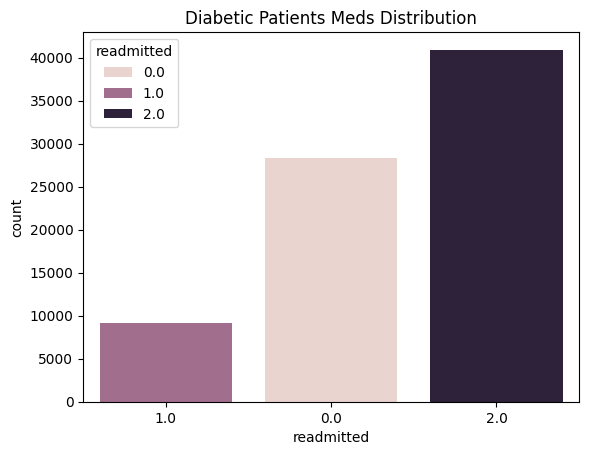

In [79]:
# visualize using Seaborn countplot; <30, >30, No => array([0., 1., 2.])
sns.countplot(x=df_diabetic['readmitted'], data=df_diabetic, hue=df_diabetic['readmitted'],
              order=df_diabetic['readmitted'].value_counts(ascending=True).index)

plt.title('Diabetic Patients Meds Distribution')
plt.show()

In [80]:
df_diabetic.info()

<class 'pandas.DataFrame'>
Index: 78363 entries, 0 to 101765
Data columns (total 58 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   patient_nbr                        78363 non-null  int64         
 1   race                               78363 non-null  str           
 2   gender                             78363 non-null  str           
 3   age                                78363 non-null  str           
 4   weight                             78363 non-null  str           
 5   created_date                       78363 non-null  datetime64[us]
 6   last_modified                      78363 non-null  datetime64[us]
 7   encounter_id                       78363 non-null  int64         
 8   admission_type_id                  78363 non-null  int64         
 9   admission_source_id                78363 non-null  int64         
 10  discharge_disposition_id           78363 non-null

In [81]:
df_diabetic['readmitted'].unique()

array([0., 1., 2.])

In [82]:
# readmit_code = ['>30', '<30', 'No']
# oe2 = OrdinalEncoder(categories=[readmit_code])

# df_diabetic['metforminPioglitazone'] = oe.fit_transform(df_diabetic[['metforminPioglitazone']])

In [83]:
# df_diabetic['readmitted'] = oe2.fit_transform(df_diabetic[['readmitted']])

In [84]:
df_diabetic.head()

,patient_nbr,race,gender,age,weight,created_date,last_modified,encounter_id,admission_type_id,admission_source_id,discharge_disposition_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_1_desc,diag_2,diag_2_desc,diag_3,diag_3_desc,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,acetohexamide,glimepiride,glipizide,glyburide,tolbutamide,tolazamide,examide,pioglitazone,rosiglitazone,troglitazone,acarbose,miglitol,citoglipton,insulin,glyburideMetformin,glipizideMetformin,glimepiridePioglitazone,metforminRosiglitazone,metforminPioglitazone,change_in_meds,diabetesMed,readmitted,admission_source_description,admission_type_description,discharge_disposition_description
0,135,Caucasian,Female,50-60,Not Captured,2026-05-04 19:13:04,2026-05-04 19:13:04,26264286,1,7,1,3,Not Captured,Surgery-Cardiovascular/Thoracic,31,1,14,0,0,1,998,INJURY AND POISONING (800-999),41,INFECTIOUS AND PARASITIC DISEASES (001-139),250,"ENDOCRINE, NUTRITIONAL AND METABOLIC DISEASES,...",5,None,None,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Change,Yes,0.0,Emergency Room,Emergency,Discharged to home
1,135,Caucasian,Female,50-60,Not Captured,2026-05-04 19:13:04,2026-05-04 19:13:04,24437208,2,1,1,8,Not Captured,Cardiology,77,6,33,0,0,0,401,DISEASES OF THE CIRCULATORY SYSTEM (390-459),997,INJURY AND POISONING (800-999),560,DISEASES OF THE DIGESTIVE SYSTEM (520-579),8,None,None,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Change,Yes,1.0,Physician Referral,Urgent,Discharged to home
3,729,Caucasian,Female,80-90,Not Captured,2026-05-04 19:13:04,2026-05-04 19:13:04,189899286,1,7,3,4,MC,Internal Medicine,68,2,23,0,0,0,820,INJURY AND POISONING (800-999),493,DISEASES OF THE RESPIRATORY SYSTEM (460-519),E880,SUPPLEMENTARYCLASSIFICATION OF EXTERNAL CAUSES...,9,None,>7,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No Change,Yes,2.0,Emergency Room,Emergency,Discharged/transferred to SNF
4,774,Caucasian,Female,80-90,Not Captured,2026-05-04 19:13:04,2026-05-04 19:13:04,64331490,1,7,1,3,Not Captured,Internal Medicine,46,0,20,0,0,0,274,"ENDOCRINE, NUTRITIONAL AND METABOLIC DISEASES,...",427,DISEASES OF THE CIRCULATORY SYSTEM (390-459),416,DISEASES OF THE CIRCULATORY SYSTEM (390-459),9,None,>8,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Change,Yes,2.0,Emergency Room,Emergency,Discharged to home
5,927,African American,Female,30-40,Not Captured,2026-05-04 19:13:04,2026-05-04 19:13:04,14824206,1,7,1,5,Not Captured,Internal Medicine,49,0,5,0,0,0,590,DISEASES OF THE GENITOURINARY SYSTEM (580-629),220,NEOPLASMS (140-239),250,"ENDOCRINE, NUTRITIONAL AND METABOLIC DISEASES,...",3,None,None,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No Change,Yes,2.0,Emergency Room,Emergency,Discharged to home


In [85]:
# run model
from sklearn.model_selection import train_test_split
# x = df_diabetic.iloc[:, 0:1]
# y = df_diabetic.iloc[:, 1]
# y
# X = df_diabetic['readmitted']
X = df_diabetic.iloc[:, 54:55]
# X = df_diabetic.iloc[:, 11:12]
X
# y = df_diabetic.iloc[:, 29:30]
# y

,readmitted
0,0.0
1,1.0
3,2.0
4,2.0
5,2.0
...,...
101760,2.0
101762,2.0
101763,2.0
101764,0.0


In [86]:
y = df_diabetic.iloc[:, 29:30]
y

,metformin
0,1.0
1,1.0
3,1.0
4,1.0
5,0.0
...,...
101760,0.0
101762,0.0
101763,1.0
101764,2.0


In [87]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=11)

In [88]:
X_train.shape

(62690, 1)

In [89]:
X_test.shape

(15673, 1)

In [90]:
y_train.shape

(62690, 1)

In [91]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [92]:
model.fit(X_train, y_train)

/opt/anaconda3/envs/myutdenv/lib/python3.14/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [93]:
y_pred = model.predict(X_test)

In [94]:
model.score(X_test, y_test) # 75% data is inherently good

0.7481656351687616

In [95]:
from sklearn.metrics import confusion_matrix

In [96]:
print(confusion_matrix(y_test, y_pred))

[[11726     0     0     0]
 [ 3625     0     0     0]
 [  209     0     0     0]
 [  113     0     0     0]]


In [97]:
from sklearn.metrics import classification_report

In [98]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.75      1.00      0.86     11726
         1.0       0.00      0.00      0.00      3625
         2.0       0.00      0.00      0.00       209
         3.0       0.00      0.00      0.00       113

    accuracy                           0.75     15673
   macro avg       0.19      0.25      0.21     15673
weighted avg       0.56      0.75      0.64     15673



/opt/anaconda3/envs/myutdenv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/myutdenv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/myutdenv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 